In [7]:
# Import required libraries
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to path so src modules can be imported
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.config import PROCESSED_DATA_DIR

sns.set_style("whitegrid")


In [8]:
# Load the cleaned combined dataset
df = pd.read_csv(PROCESSED_DATA_DIR / "cleaned_combined.csv")

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(2)


Shape: (118988, 11)
Columns: ['label', 'text', 'num_urls', 'num_exclamation', 'num_question', 'num_dollar', 'num_all_caps', 'num_numbers', 'word_count', 'capital_ratio', 'emoji_count']


,label,text,num_urls,num_exclamation,num_question,num_dollar,num_all_caps,num_numbers,word_count,capital_ratio,emoji_count
0,0,receiv nahou-msmbx01v [phonenumber] nahou- mic...,41,0,0,3,240,407,2319,0.145347,0
1,0,receiv nahou- [phonenumber] nacal-msmbx01v mic...,0,1,0,0,19,56,166,0.230851,0


In [9]:
# Display data types and memory usage
df.info()

print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDuplicate texts: {df['text'].duplicated().sum()}")


<class 'pandas.DataFrame'>
RangeIndex: 118988 entries, 0 to 118987
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   label            118988 non-null  int64  
 1   text             118988 non-null  str    
 2   num_urls         118988 non-null  int64  
 3   num_exclamation  118988 non-null  int64  
 4   num_question     118988 non-null  int64  
 5   num_dollar       118988 non-null  int64  
 6   num_all_caps     118988 non-null  int64  
 7   num_numbers      118988 non-null  int64  
 8   word_count       118988 non-null  int64  
 9   capital_ratio    118988 non-null  float64
 10  emoji_count      118988 non-null  int64  
dtypes: float64(1), int64(9), str(1)
memory usage: 10.0 MB

Missing values:
label              0
text               0
num_urls           0
num_exclamation    0
num_question       0
num_dollar         0
num_all_caps       0
num_numbers        0
word_count         0
capital_ratio      0
emo

label
1    60378
0    58610
Name: count, dtype: int64

Spam percentage: 50.74%
Ham percentage:  49.26%


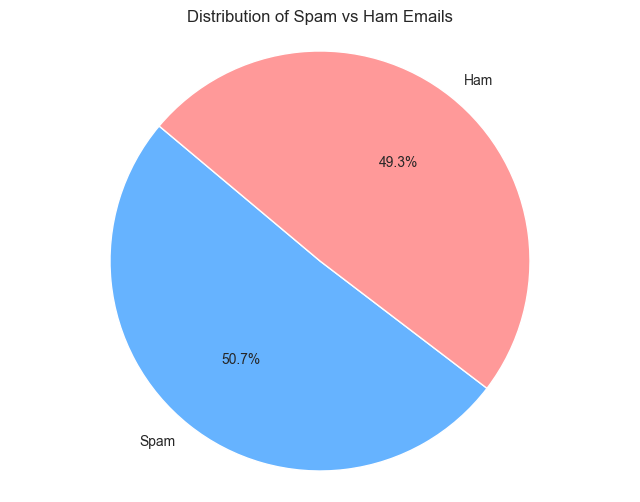

In [10]:
# Pie chart: distribution of spam vs ham emails
labels = {0: "Ham", 1: "Spam"}
counts = df["label"].value_counts()
print(counts)
print(f"\nSpam percentage: {counts[1] / len(df) * 100:.2f}%")
print(f"Ham percentage:  {counts[0] / len(df) * 100:.2f}%")

plt.figure(figsize=(8, 6))
plt.pie(counts, labels=[labels[i] for i in counts.index],
        autopct="%1.1f%%", startangle=140, colors=["#66b3ff", "#ff9999"])
plt.title("Distribution of Spam vs Ham Emails")
plt.axis("equal")
plt.show()


In [11]:
# Group numeric features by label and compute averages
num_features = [
    "num_urls", "num_exclamation", "num_question", "num_dollar",
    "num_all_caps", "num_numbers", "word_count", "capital_ratio", "emoji_count"
]

avg_by_label = df.groupby("label")[num_features].mean().T
avg_by_label.columns = ["Ham", "Spam"]
print("Average feature values by class:")
print(avg_by_label.round(4))


Average feature values by class:
                      Ham      Spam
num_urls           2.7441    3.6833
num_exclamation    1.3018    7.1650
num_question       2.2157    4.1370
num_dollar         1.3032    8.0181
num_all_caps      42.9056   34.5333
num_numbers      713.1310  175.2476
word_count       499.6754  289.8766
capital_ratio      0.1739    0.1632
emoji_count        0.0573    0.4830


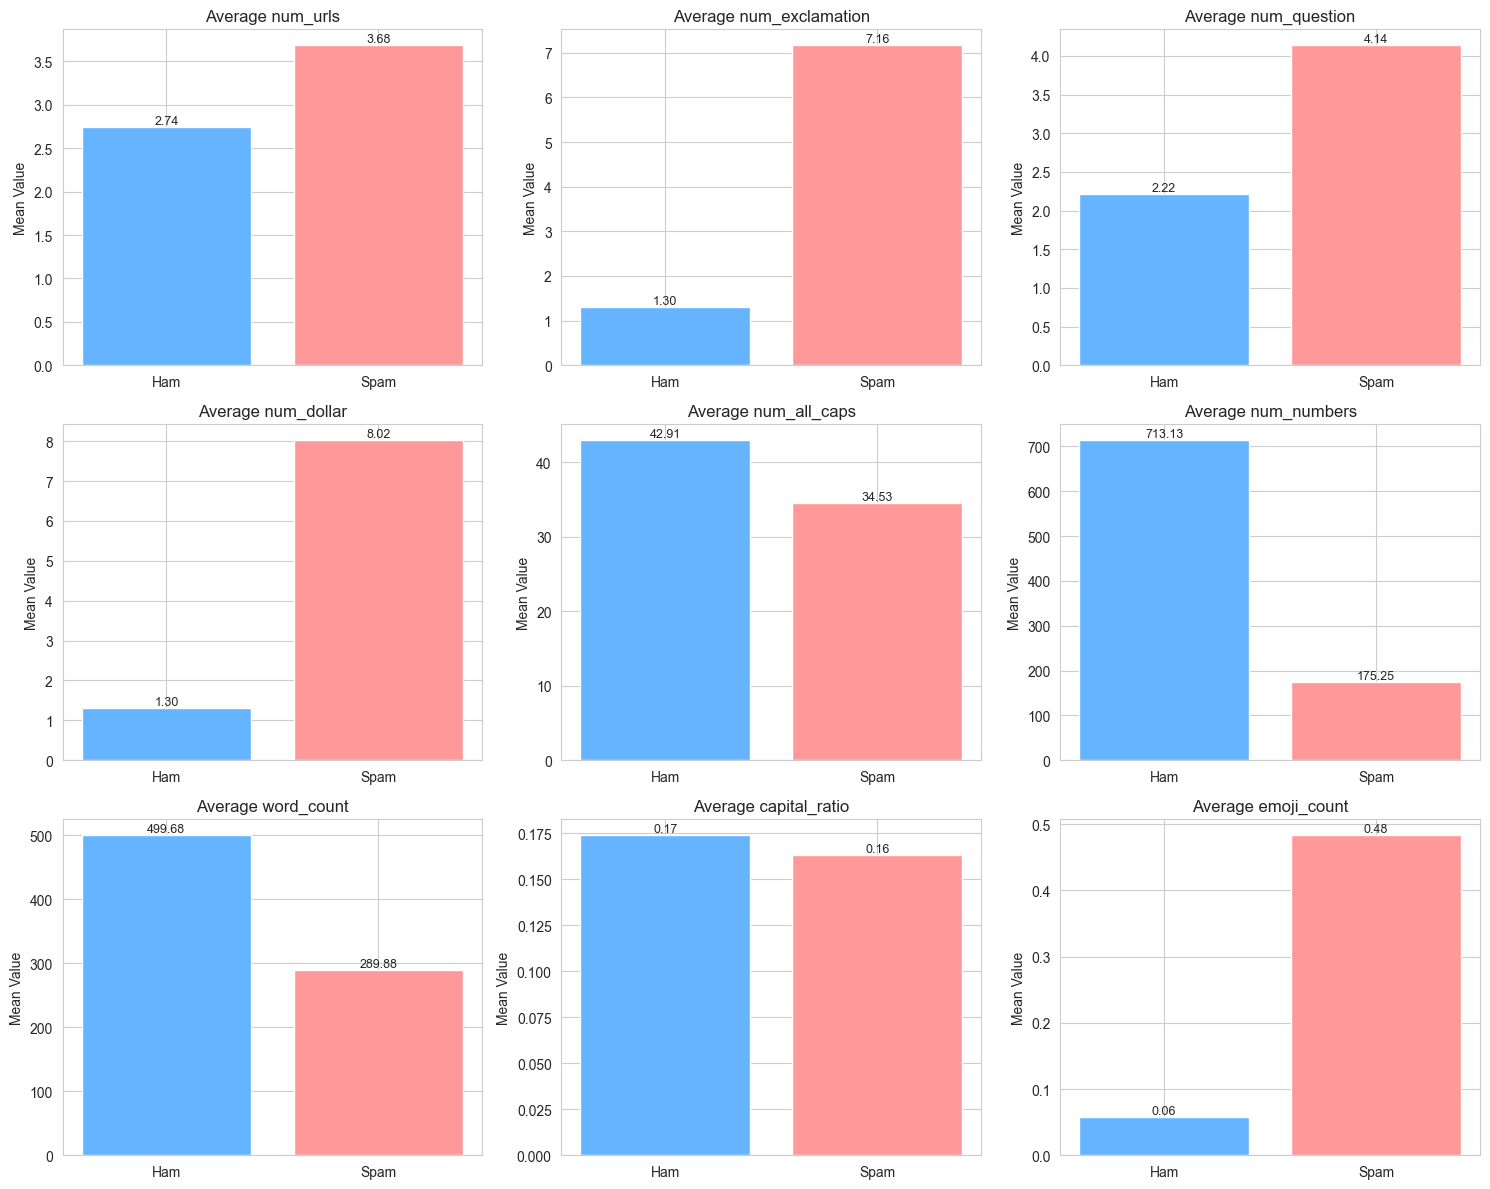

In [12]:
# Bar charts comparing average feature values between spam and ham
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(num_features):
    means = df.groupby("label")[feature].mean()
    axes[i].bar(["Ham", "Spam"], means, color=["#66b3ff", "#ff9999"])
    axes[i].set_title(f"Average {feature}")
    axes[i].set_ylabel("Mean Value")
    # Annotate each bar with its value
    for j, v in enumerate(means):
        axes[i].text(j, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


In [13]:
# Emoji count analysis: which class uses more emojis?
emoji_means = df.groupby("label")["emoji_count"].mean()
print("Average emoji count:")
print(emoji_means)

# Row with highest emoji count in spam emails
print("\nSpam email with most emojis:")
display(df[df["label"] == 1].sort_values(by="emoji_count", ascending=False).head(1))

# Row with highest emoji count in ham emails
print("Ham email with most emojis:")
display(df[df["label"] == 0].sort_values(by="emoji_count", ascending=False).head(1))


Average emoji count:
label
0    0.05726
1    0.48299
Name: emoji_count, dtype: float64

Spam email with most emojis:


,label,text,num_urls,num_exclamation,num_question,num_dollar,num_all_caps,num_numbers,word_count,capital_ratio,emoji_count
72271,1,receiv nahou- [phonenumber] nahou- microsoft s...,1,0,8,0,43,565,2248,0.237829,1427


Ham email with most emojis:


,label,text,num_urls,num_exclamation,num_question,num_dollar,num_all_caps,num_numbers,word_count,capital_ratio,emoji_count
39557,0,receiv nahou- [phonenumber] nahou- microsoft s...,7,2,37,419,347,2495,41913,0.050809,40


In [14]:
# Exclamation and dollar sign patterns (common in spam)
print("Average exclamation marks:")
print(df.groupby("label")["num_exclamation"].mean())

print("\nAverage dollar signs:")
print(df.groupby("label")["num_dollar"].mean())

print("\nAverage question marks:")
print(df.groupby("label")["num_question"].mean())


Average exclamation marks:
label
0    1.301792
1    7.164977
Name: num_exclamation, dtype: float64

Average dollar signs:
label
0    1.303208
1    8.018069
Name: num_dollar, dtype: float64

Average question marks:
label
0    2.215731
1    4.137020
Name: num_question, dtype: float64


In [15]:
# URL, all-caps, and word count patterns
print("Average URL count:")
print(df.groupby("label")["num_urls"].mean())

print("\nAverage all-caps word count:")
print(df.groupby("label")["num_all_caps"].mean())

print("\nAverage word count:")
print(df.groupby("label")["word_count"].mean())

print("\nAverage capital ratio:")
print(df.groupby("label")["capital_ratio"].mean())


Average URL count:
label
0    2.744122
1    3.683345
Name: num_urls, dtype: float64

Average all-caps word count:
label
0    42.905630
1    34.533257
Name: num_all_caps, dtype: float64

Average word count:
label
0    499.675363
1    289.876578
Name: word_count, dtype: float64

Average capital ratio:
label
0    0.173863
1    0.163177
Name: capital_ratio, dtype: float64


Average number count:
label
0    713.130984
1    175.247574
Name: num_numbers, dtype: float64


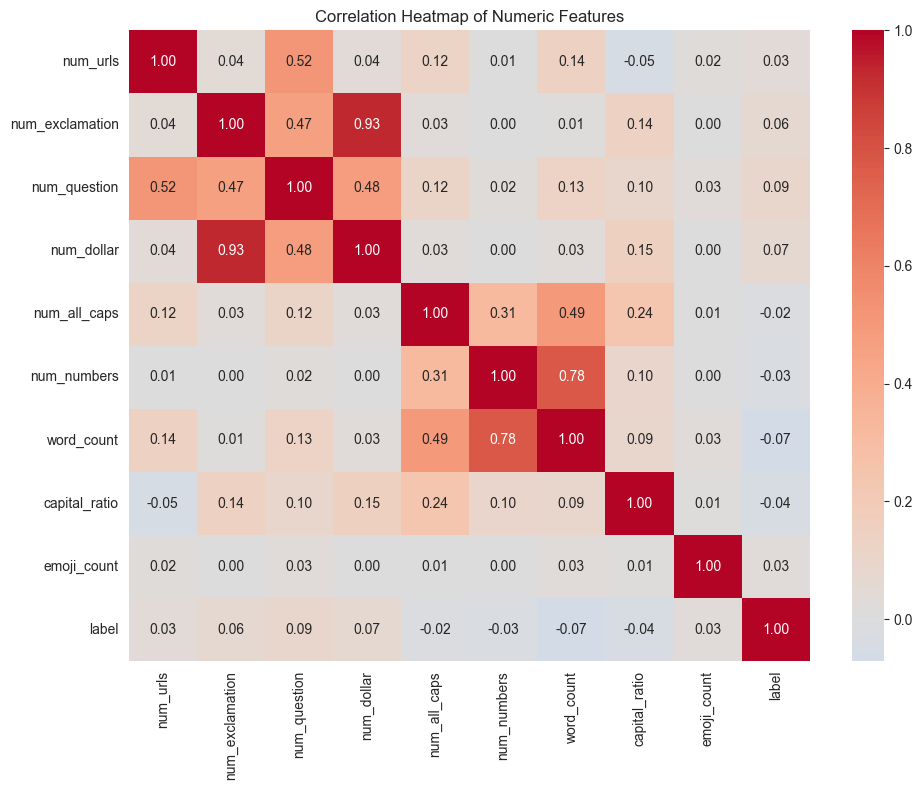

In [16]:
# Number count patterns
print("Average number count:")
print(df.groupby("label")["num_numbers"].mean())

# Correlation heatmap to see relationships between numeric features
plt.figure(figsize=(10, 8))
corr = df[num_features + ["label"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()


Average text length by class:
label
0    3369.193960
1    1596.246497
Name: text_length, dtype: float64


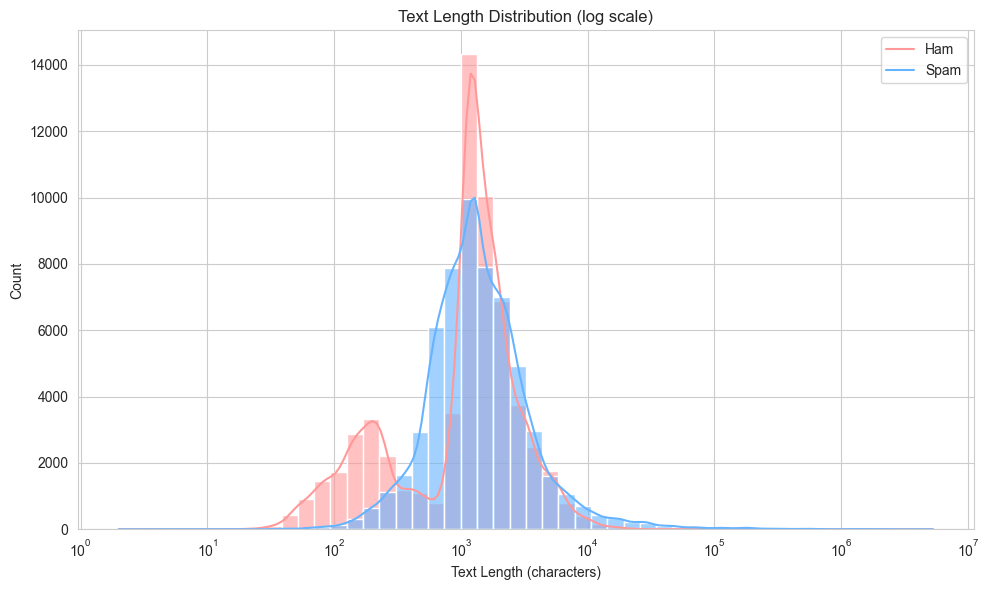

In [17]:
# Text length distribution
df["text_length"] = df["text"].str.len()

print("Average text length by class:")
print(df.groupby("label")["text_length"].mean())

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="text_length", hue="label", bins=50,
             kde=True, palette={0: "#66b3ff", 1: "#ff9999"},
             alpha=0.6, log_scale=True)
plt.title("Text Length Distribution (log scale)")
plt.xlabel("Text Length (characters)")
plt.ylabel("Count")
plt.legend(labels=["Ham", "Spam"])
plt.tight_layout()
plt.show()
